In [1]:
!pip install roboflow
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import os

# Your Roboflow snippet (ensure your API key is correct)
from roboflow import Roboflow
rf = Roboflow(api_key="rlFp0Gl96481slJPZ8y6")
project = rf.workspace("pc-r3hpl").project("brain-tumor-x60pu")
version = project.version(1)
dataset = version.download("coco") # Note: ResNet classification usually uses folder-based datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.6/94.6 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 92.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 118.6 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to BRAIN-TUMOR-1 in coco:: 100%|██████████| 1310/1310 [00:00<00:00, 9013.26it/s]


In [4]:
DATASET_PATH = dataset.location
print(f"Dataset downloaded to: {DATASET_PATH}")

Dataset downloaded to: /content/BRAIN-TUMOR-1


In [6]:
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torch
import torch.nn as nn

class SingleClassDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        # Filter for image files only
        self.image_files = [f for f in os.listdir(root_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = os.path.join(self.root_dir, self.image_files[idx])
        image = Image.open(img_name).convert('RGB')
        if self.transform:
            image = self.transform(image)

        # Since there is only one class (Tumor), the label is always 0
        label = 0
        return image, label

# Path from your error message
TRAIN_DIR = '/content/BRAIN-TUMOR-1/train'

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dataset = SingleClassDataset(root_dir=TRAIN_DIR, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

print(f"Successfully loaded {len(train_dataset)} images.")

Successfully loaded 1072 images.


In [7]:
# Load ResNet18
model = models.resnet18(pretrained=True)

# We modify the output layer, but since it's 1 class,
# we usually use 1 output neuron with a Sigmoid for "Confidence"
model.fc = nn.Linear(model.fc.in_features, 1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 211MB/s]


In [8]:
import torch.optim as optim

# 1. Define Loss and Optimizer
# Using BCE because we are treating this as a "Confidence" task (0 to 1)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# 2. Training Loop
def train_one_class(model, loader, epochs=10):
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for images, _ in loader: # Labels are all 0, so we ignore them or use dummy 1s
            images = images.to(device)
            # Creating dummy target of '1' because we want the model to
            # recognize these features as the "positive" class
            targets = torch.ones((images.size(0), 1)).to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch [{epoch+1}/{epochs}] - Loss: {running_loss/len(loader):.4f}")

# Run training
train_one_class(model, train_loader, epochs=10)

Epoch [1/10] - Loss: 0.1075
Epoch [2/10] - Loss: 0.0098
Epoch [3/10] - Loss: 0.0050
Epoch [4/10] - Loss: 0.0033
Epoch [5/10] - Loss: 0.0024
Epoch [6/10] - Loss: 0.0019
Epoch [7/10] - Loss: 0.0015
Epoch [8/10] - Loss: 0.0012
Epoch [9/10] - Loss: 0.0010
Epoch [10/10] - Loss: 0.0009


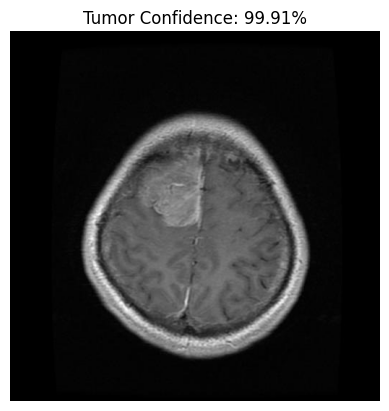

In [9]:
import matplotlib.pyplot as plt

def predict_tumor(image_path, model):
    model.eval()
    img = Image.open(image_path).convert('RGB')
    img_t = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        prediction = torch.sigmoid(model(img_t))
        confidence = prediction.item() * 100

    plt.imshow(img)
    plt.title(f"Tumor Confidence: {confidence:.2f}%")
    plt.axis('off')
    plt.show()

# Test it on the first image in your folder
sample_img = os.path.join(TRAIN_DIR, os.listdir(TRAIN_DIR)[0])
predict_tumor(sample_img, model)